In [1]:
import numpy as np
import scipy as sp
import math
import matplotlib.pyplot as plt
import seaborn as sns

### Распределение для заданий 1 и 2: $$\mathcal{F}(3, 5)$$

**Задание №1. Пусть ξ1, ξ2, . . . — последовательность независимых случайных величин из заданного распределения. Привести графическую иллюстрацию закона больших чисел.**

In [2]:
np.random.seed(42)
d1, d2 = 3, 5
E_x = d2 / (d2 - 2)
D_x = 2 * d2 ** 2 * (d1 + d2 - 2) / (d1 * (d2 - 2) ** 2 * (d2 - 4))
n = 10 ** 5
samples = np.random.f(dfnum=d1, dfden=d2, size=n)
samples

array([1.51448415, 0.8438402 , 1.82590002, ..., 1.03287499, 3.02213933,
       0.73507015])

In [3]:
S_n = np.cumsum(samples)
N = np.arange(1, len(samples) + 1)
S_n /= N
S_n

array([1.51448415, 1.17916218, 1.39474146, ..., 1.65504389, 1.65505756,
       1.65504836])

**ЗБЧ (Хинчина): $$ \text{Пусть }X_1, X_2,X_3,... - iid, \,\,\mathbb{E}|X_1|\lt\infty, \,\,S_0=0, \,\,S_n=\sum_{k=1}^n X_k $$ 
Тогда $$ \frac{S_n}{n}=\frac{X_1 + X_2 +...+ X_n}{n}\xrightarrow{P}\mathbb{E}X_1$$**

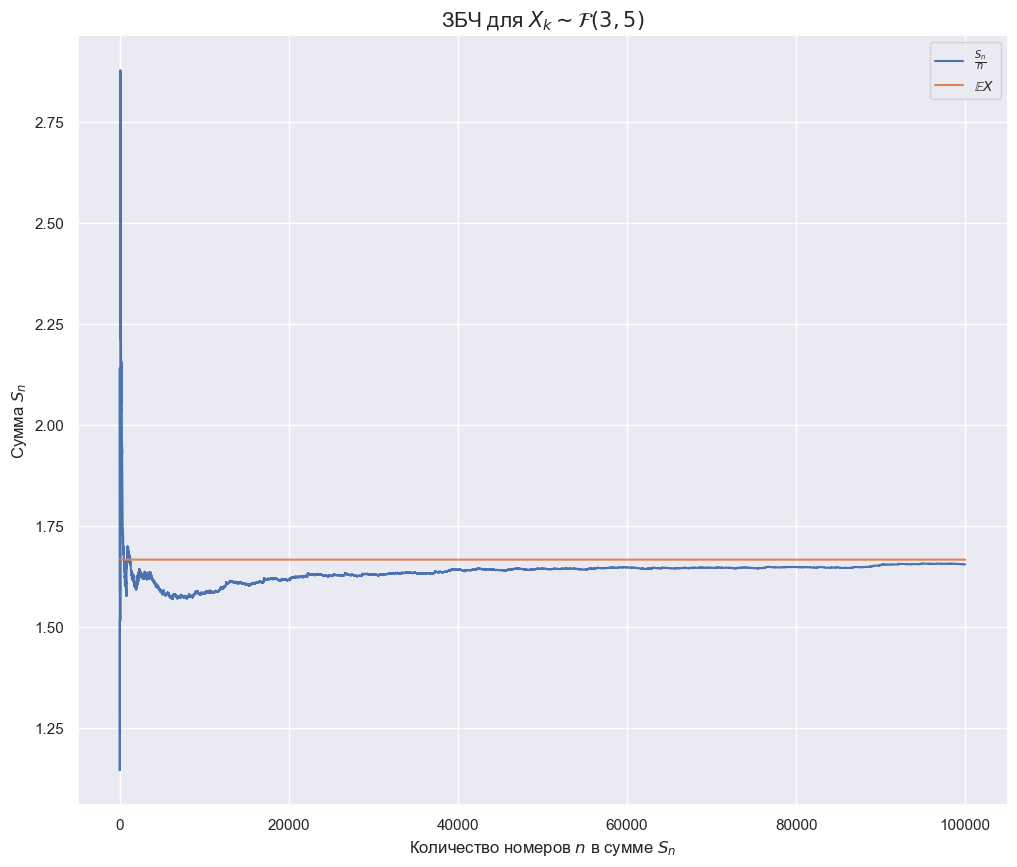

In [4]:
sns.set_theme(style='darkgrid', palette='deep')
plt.figure(figsize=(12, 10))

sns.lineplot(x=np.arange(n), y=S_n, label='$\\frac{S_n}{n}$')
sns.lineplot(x=np.arange(n), y=np.full_like(a=samples, fill_value=E_x), label='$\mathbb{E}X$')

plt.xlabel('Количество номеров $n$ в сумме $S_n$')
plt.ylabel('Сумма $S_n$')
plt.title('ЗБЧ для $X_k \sim \mathcal{F}(3, 5)$', fontsize=15)
plt.legend(fontsize=10)
plt.show()

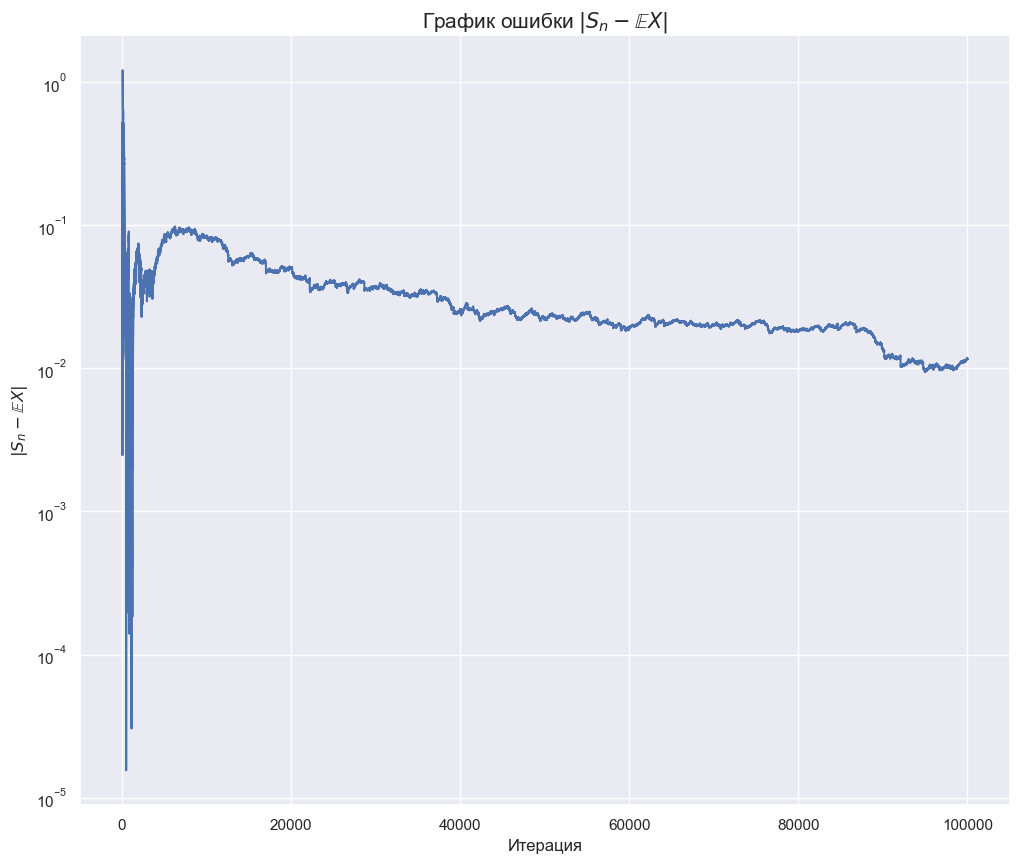

In [5]:
plt.figure(figsize=(12, 10))

sns.lineplot(x = np.arange(n), y = np.abs(S_n - np.full_like(a=samples, fill_value=E_x)))

plt.yscale('log')
plt.ylabel('$|S_n-\mathbb{E}X|$')
plt.xlabel('Итерация')
plt.title('График ошибки $|S_n-\mathbb{E}X|$', fontsize=15)
plt.show()

In [6]:
upp_bound = 3 * math.sqrt(D_x / n)
low_bound = -3 * math.sqrt(D_x / n)

ub_array = np.full_like(a=samples, fill_value=upp_bound)
lb_array = np.full_like(a=samples, fill_value=low_bound)

Err = S_n - E_x

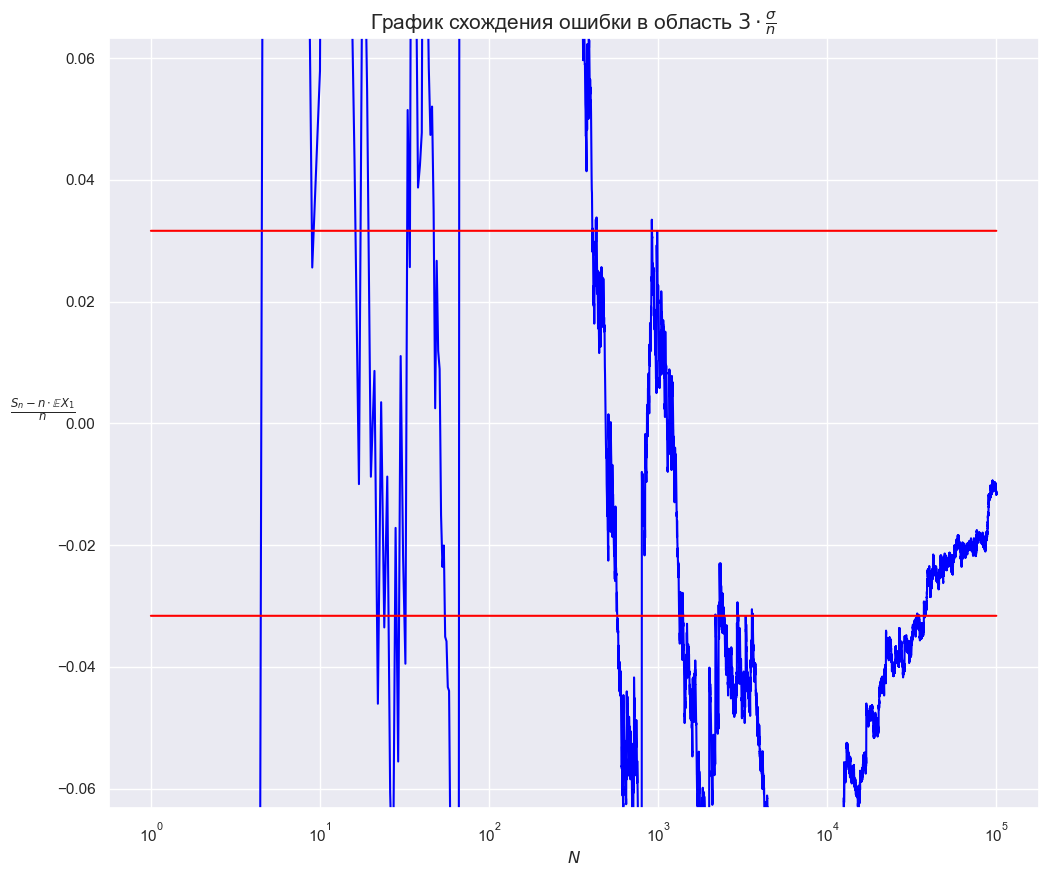

In [7]:
plt.figure(figsize=(12, 10))

plt.ylim(2 * low_bound, 2 * upp_bound)
plt.xscale('log')
sns.lineplot(x=N, y=Err, color='blue')
sns.lineplot(x=N, y=ub_array, color='red')
sns.lineplot(x=N, y=lb_array, color='red')

plt.title('График схождения ошибки в область $3\cdot\\frac{\\sigma}{n}$', fontsize=15)

plt.xlabel('$N$', fontsize=12)
plt.ylabel('$\\frac{S_n-n\cdot\mathbb{E}X_1}{n}$', fontsize=12, ha='center', va='bottom', rotation=0, labelpad=10)
plt.show()

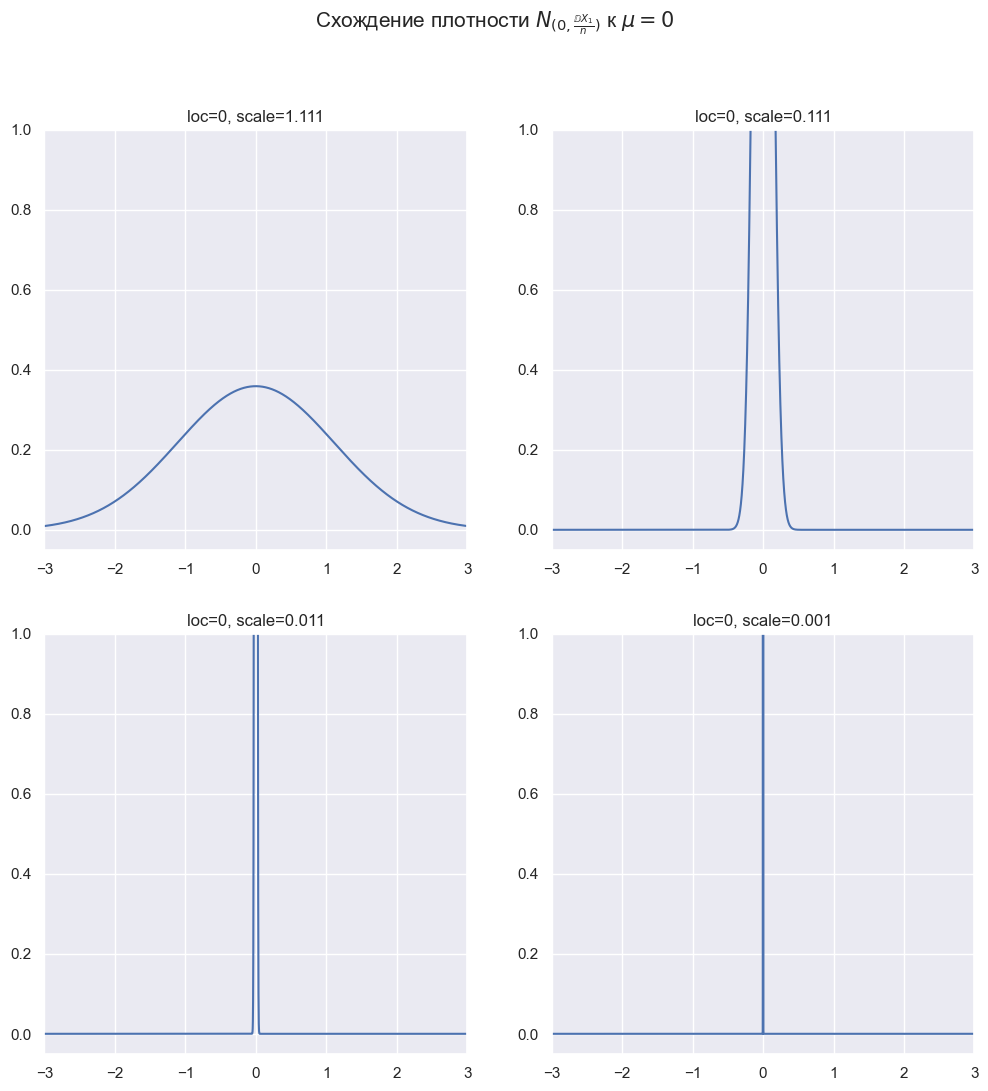

In [8]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 12))
std_vals = np.array([D_x / 10, D_x / 100, D_x / 1000, D_x / 10000]).reshape(-1, 2)
x = np.linspace(-3, 3, 10000)

for i in range(2):
    for j in range(2):
        ax[i, j].set_xlim(-3, 3)
        ax[i, j].set_ylim(-0.05)
        ax[i, j].plot(x, sp.stats.norm.pdf(x, loc=0, scale=std_vals[i, j]))
        ax[i, j].set_title(f'loc=0, scale={std_vals[i, j].round(3)}')

fig.suptitle('Схождение плотности $N_{(0, \\frac{\\mathbb{D}X_1}{n})}$ к $\\mu=0$', fontsize=15)
plt.show()

#### По графикам можно заметить, что $\frac{S_n}{n}\xrightarrow{P}\mathbb{E}X_1$

**Задание №2. Пусть ξ1, ξ2, . . . — последовательность независимых случайных величин из заданного распределения. Привести графическую иллюстрацию центральной предельной теоремы**

**ЦПТ: $$\text{Пусть } X_1, X_2, X_3,... - iid,\,\,\mathbb{D}X_1\in(0, \infty),\,\,S_0=0,\,\,S_n=\sum_{k=1}^n X_K$$
Тогда: $$ \frac{S_n - \mathbb{E}S_n}{\sqrt{\mathbb{D}S_n}} = \frac{S_n - n\mathbb{E}X_1}{\sqrt{n\mathbb{D}X_1}}\xrightarrow{d}\eta\sim\\N_{0, 1}$$**

In [9]:
np.random.seed(50)
d1, d2 = 3, 5
n = 10**4
m = 10**4
samples = np.random.f(dfnum=d1, dfden=d2, size=(m, n))
samples

array([[ 0.12774193,  3.74172757,  0.57884186, ...,  1.00037145,
         1.41852699,  2.14288978],
       [ 1.88293317,  0.39558754,  4.21138942, ...,  3.74892471,
         0.95987251,  0.85094643],
       [ 0.83890982,  3.41972524,  2.23096952, ...,  1.29307461,
         6.93261532,  3.67804026],
       ...,
       [ 0.61550875,  0.19877916,  4.9812118 , ...,  1.69887935,
         0.34400551,  1.48742446],
       [ 0.51039139, 15.29775501,  1.31598208, ...,  1.18199862,
         0.17743037,  0.34471638],
       [ 4.4374079 ,  0.84227687,  4.3803999 , ..., 10.46013055,
         3.45130477,  0.22882873]])

In [10]:
E_x = d2 / (d2 - 2)
D_x = 2 * d2 ** 2 * (d1 + d2 - 2) / (d1 * (d2 - 2) ** 2 * (d2 - 4))
E_x, D_x

(1.6666666666666667, 11.11111111111111)

In [11]:
S_n = np.sum(samples, axis=1)
N = np.full_like(a=S_n, fill_value=n)
S_n, N

(array([16672.78024256, 16718.22741924, 16977.06543341, ...,
        16420.93273962, 16601.44816005, 16466.34143637]),
 array([10000., 10000., 10000., ..., 10000., 10000., 10000.]))

**Создадим случайную величину: $$Y_n = \frac{\sum_{i=1}^n X_i - n\mu}{\sigma \sqrt{n}}$$**

In [12]:
Y = (S_n - (N * E_x)) / np.sqrt(N * D_x)
Y

array([ 0.01834073,  0.15468226,  0.9311963 , ..., -0.73720178,
       -0.19565552, -0.60097569])

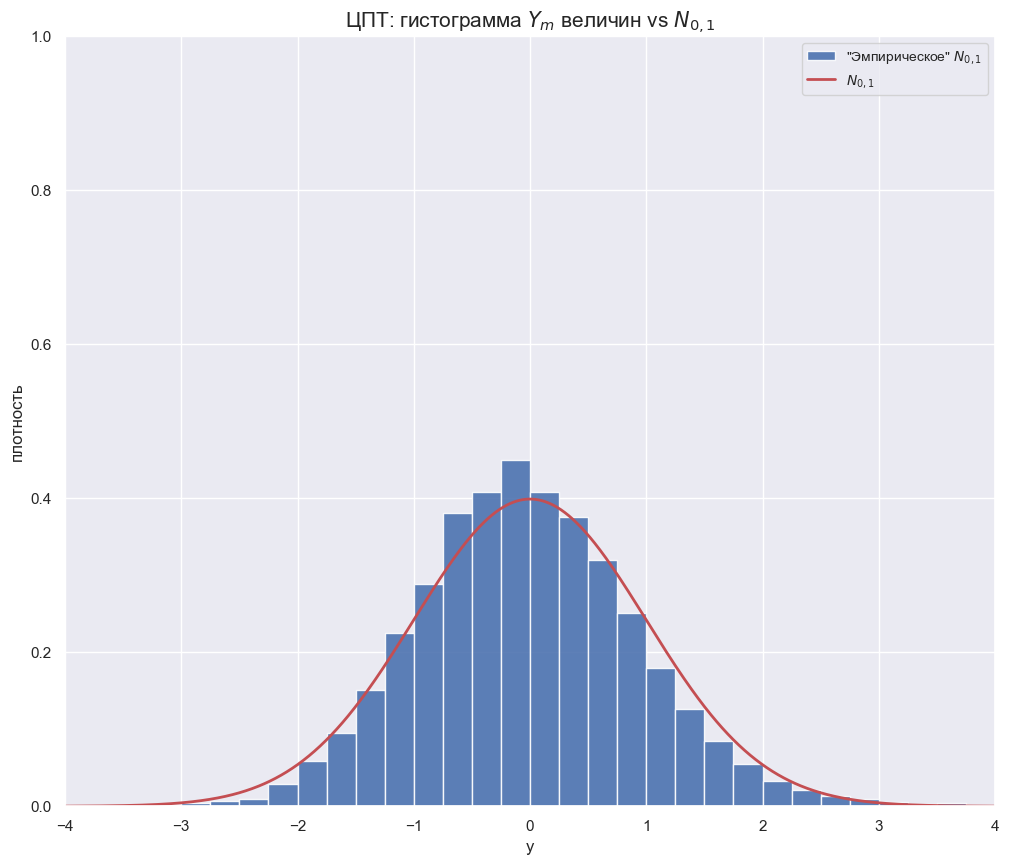

In [13]:
plt.figure(figsize=(12, 10))
bins = np.arange(-4, 4, 0.25)

plt.hist(Y, bins=bins, density=True, alpha=0.9, label='"Эмпирическое" $N_{0, 1}$')

x = np.linspace(-4, 4, 1000)
plt.plot(x, sp.stats.norm.pdf(x), 'r', lw=2, label='$N_{0,1}$')

plt.legend(fontsize=10)
plt.xlim(-4, 4)
plt.ylim(0, 1)
plt.xlabel('y')
plt.ylabel('плотность')
plt.title('ЦПТ: гистограмма $Y_m$ величин vs $N_{0,1}$', fontsize=15)
plt.show()

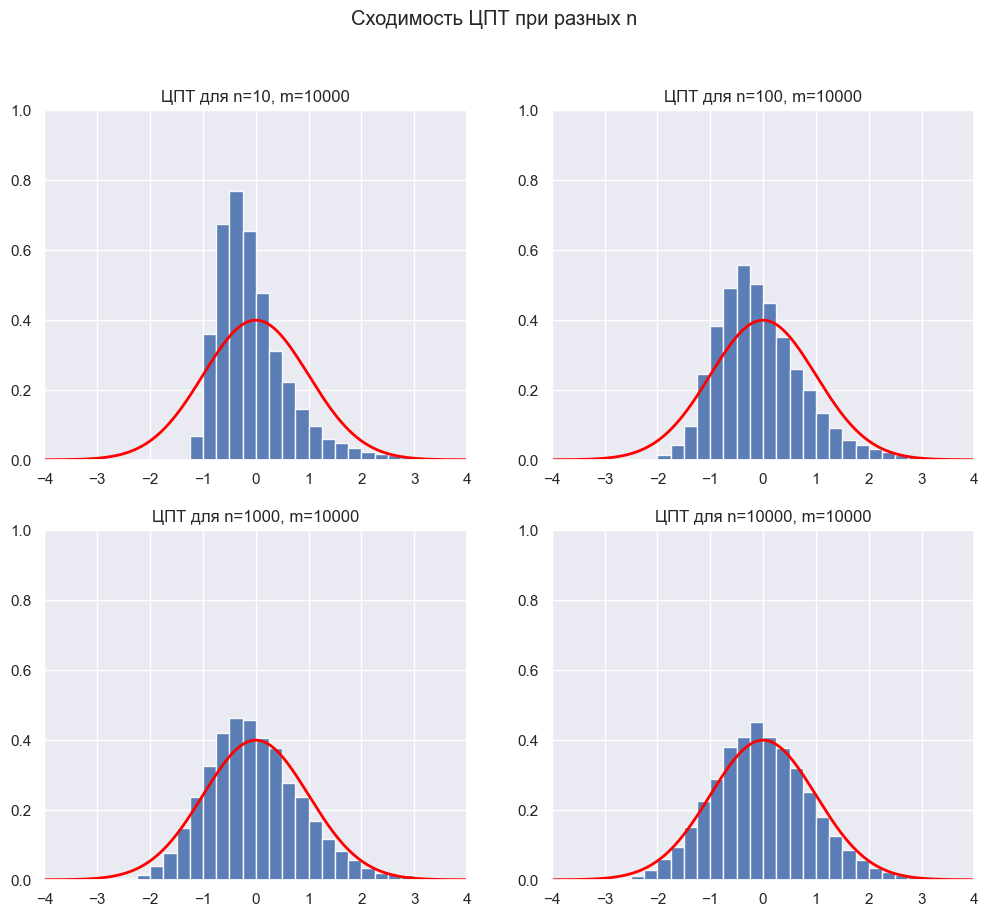

In [14]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
x = np.linspace(-4, 4, 1000)
k = 0
bins = np.arange(-4, 4, 0.25)
for i in range(2):
    for j in range(2):
        k += 1
        S_nk = np.sum(samples[:, 0:10**k], axis=1)
        Nk = np.full_like(a=S_nk, fill_value=10**k)
        Y_n = (S_nk - (Nk * E_x)) / (np.sqrt(Nk * D_x))
        ax[i, j].set_title(f'{k}')
        ax[i, j].set_xlim(-4, 4)
        ax[i, j].set_ylim(0, 1)
        ax[i, j].hist(Y_n, bins=bins, density=True, alpha=0.9)
        ax[i, j].plot(x, sp.stats.norm.pdf(x), lw=2, color='red')
        ax[i, j].set_title(f'ЦПТ для n={10**k}, m={m}')
        #print(Y_n)

fig.suptitle('Сходимость ЦПТ при разных n')
plt.show()

**Создадим эмпирическую функцию распределения (ЭФР):**
$$
F_{n}^*(t)=\frac{\sum_{i=1}^n \mathbf{1}{(X_i < t)}}{n}
$$

In [15]:
T = np.linspace(-3, 3, 100)
etta = sp.stats.norm.cdf(T) # - ФР нормального распределения
F = np.zeros_like(T) # - ЭФР
for i in range(len(T)):
    F[i] = (np.sum(Y < T[i])) / m 

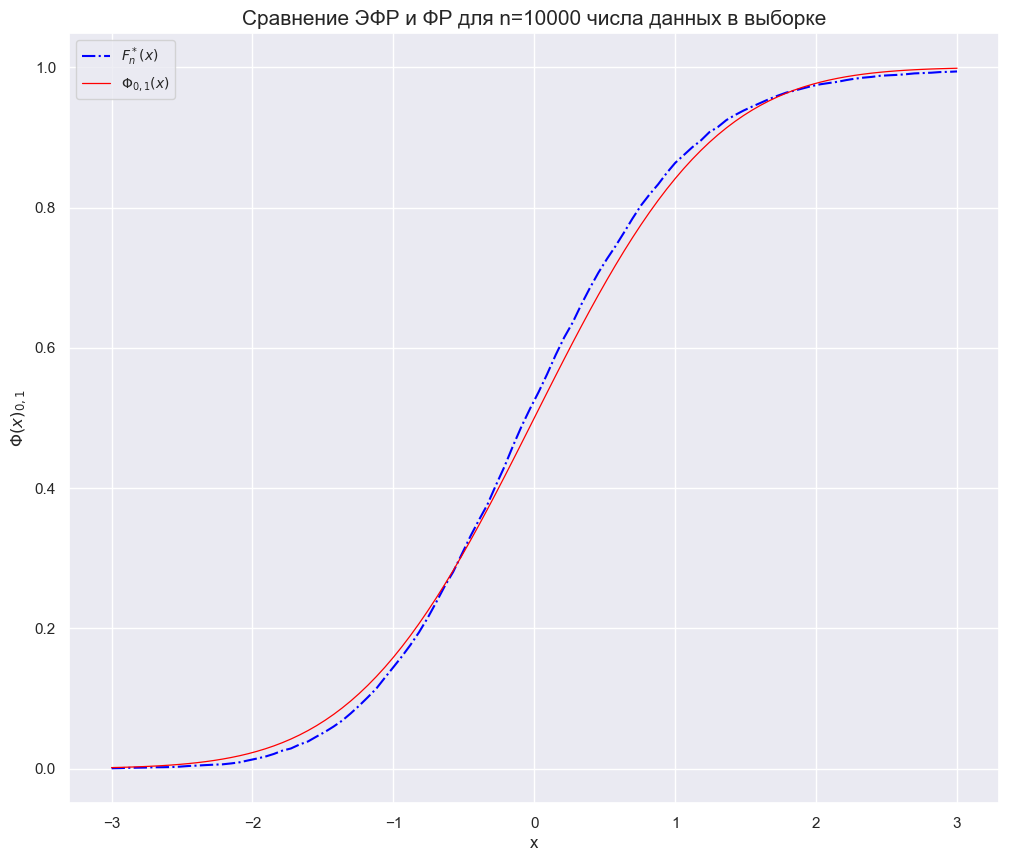

In [16]:
plt.figure(figsize=(12, 10))

sns.lineplot(x=T, y=F, label='$F_{n}^*(x)$', color='blue', linestyle='-.')
sns.lineplot(x=T, y=etta, label='$\\Phi_{0, 1}(x)$', color='red', linewidth=0.9)

plt.ylabel('$\\Phi(x)_{0, 1}$')
plt.xlabel('x')
plt.title(f'Сравнение ЭФР и ФР для n={m} числа данных в выборке', fontsize=15)
plt.legend(fontsize=10)
plt.show()

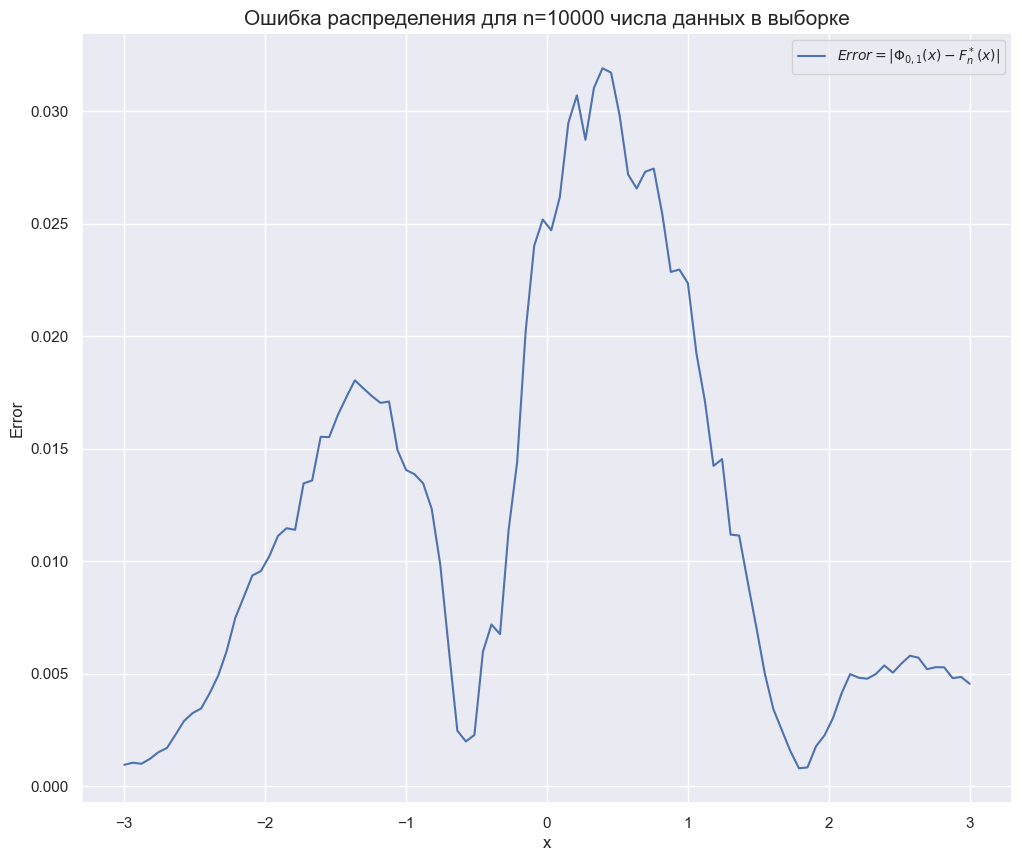

In [17]:
plt.figure(figsize=(12, 10))


sns.lineplot(x=T, y=np.abs(F - etta), label='$Error = |\\Phi_{0, 1}(x) - F_{n}^*(x)|$')

plt.ylabel('Error')
plt.xlabel('x')
plt.title(f'Ошибка распределения для n={n} числа данных в выборке', fontsize=15)
plt.legend(fontsize=10)
plt.show()

In [18]:
print('Максимальная ошибка распределения: ', np.max(etta - F))

Максимальная ошибка распределения:  0.018041020709374217


**Задание №3. Написать генератор неоднородного процесса Пуассона N(t) с заданной интенсивностью λ(t) на интервале времени [T1, T2]. Ожидаемый результат – график траектории процесса N(t). Провести серию из n (= 10, 100, 1000, 10000, . . .) симуляций, по ним эмпирически оценить интенсивность и сравнить её с заданной функцией интенсивности.**

Для данной задачи написания неоднородного ПП будем использовать метод преобразования шкалы времени для нашей функции интенсивности $\lambda(t) = \cot(\frac{t}{2})$, $t\in[\frac{\pi}{6}, \pi]$

Посчитаем сначала верхнюю оценку по времени $$ \Lambda(t)=u=2\cdot\ln(\frac{\sin{\frac{t}{2}}}{\sin{\frac{\pi}{12}}}) $$ $$\Lambda(\pi)=U = \int_\frac{\pi}{6}^{\pi} \cot(\frac{t}{2})dt = -2\cdot\ln(\sin{\frac{\pi}{12}})$$

$\text{ Пусть } f(u) = \Lambda^{-1}(u) \text{. Найдем} f(u)$:
$$ \\f(u) = t = 2 \cdot \arcsin(\sin{\frac{\pi}{12}} \cdot e^{\frac{u}{2}} ) $$

Теперь запустим однородный процесс Пуассона $N^{*}(U)$ с интенсивностью 1
$u_1 \lt u_2 \lt u_3 \lt ...$ - моменты скачков для процесса $N^{*}(U)$ 

Теперь вычислим $t_1 \lt t_2 \lt t_3 \lt ...$, подставив $u_1, u_2, u_3, ...$ в функцию $t_i = f(u_i)$

В итоге получим неоднородный процесс Пуассона $N(t)$ с интенсивностью $\lambda(t)$

In [19]:
- 2 * math.log(math.sin(math.pi / 12))

2.7032522580447074

In [20]:
f = lambda u: 2 * math.asin(math.sin(math.pi / 12) * math.exp(u / 2))

In [21]:
def nhpp(f: callable, seed=42) -> (np.int64, np.array):
    rng = np.random.default_rng(seed)
    events = []

    U = - 2 * math.log(math.sin(math.pi / 12))
    S = 0
    n = 0

    while True:
        S += np.random.exponential(scale=1)
        if S > U:
            break
        t_i = f(S)
        if math.pi / 6 <= t_i <= math.pi:
            n += 1
            events.append(t_i)
    return (n, events)

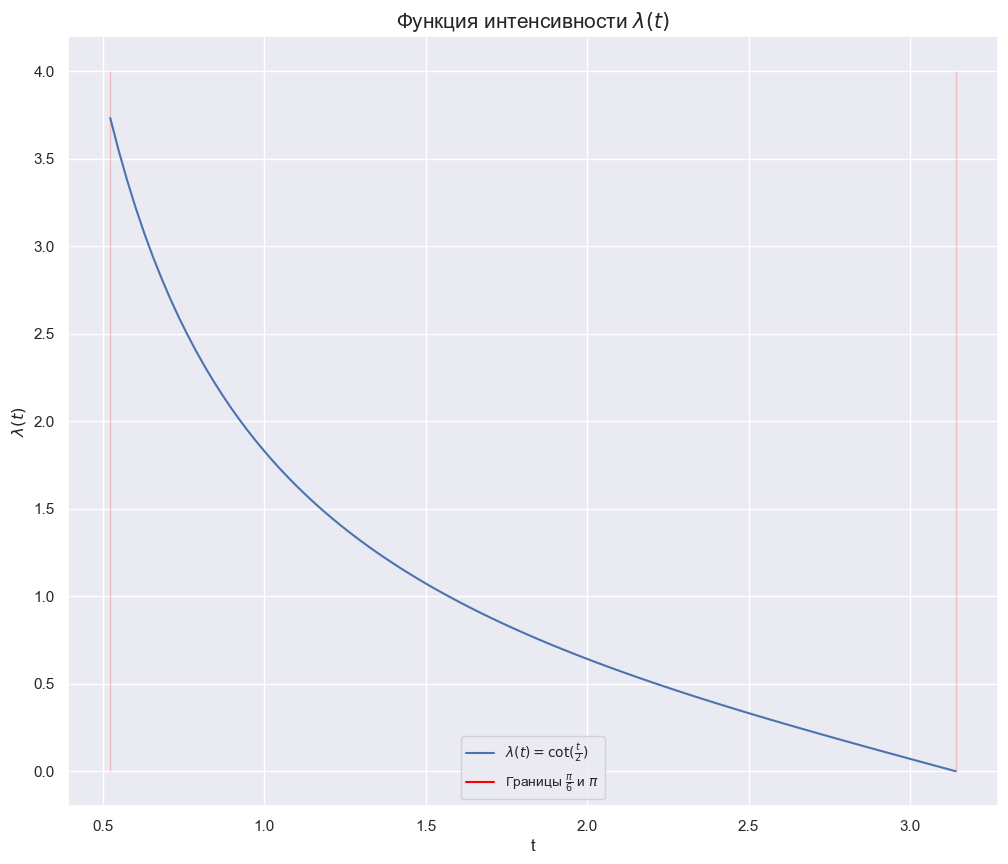

In [22]:
plt.figure(figsize=(12, 10))

x = np.linspace(math.pi / 6, math.pi, 100)
y = 1 / np.tan(x / 2)

sns.lineplot(x=x, y=y, label='$\lambda(t)=\\cot(\\frac{t}{2})$')
sns.lineplot(x= [math.pi / 6, math.pi / 6], y = [0, 4], color='red', label='Границы $\\frac{\\pi}{6}$ и $\\pi$')
sns.lineplot(x= [math.pi, math.pi], y = [0, 4], color='red')

plt.xlabel('t')
plt.ylabel('$\lambda(t)$')
plt.legend(fontsize=10)
plt.title('Функция интенсивности $\lambda(t)$', fontsize=15)
plt.show()

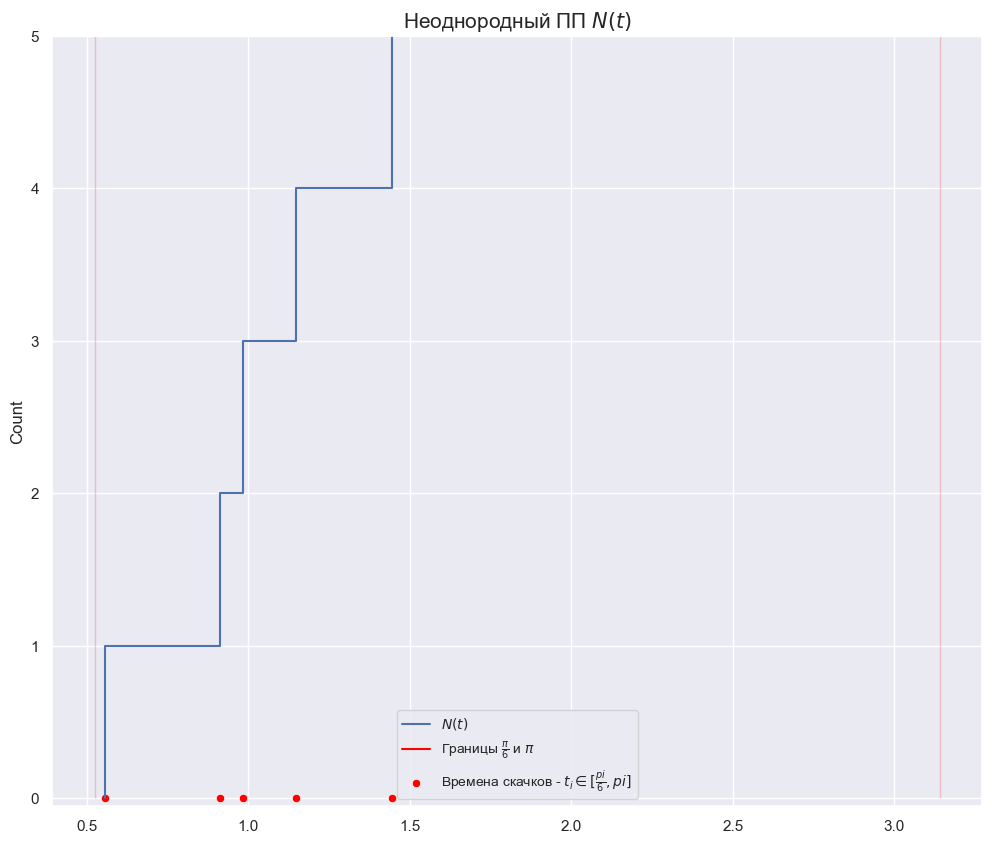

In [23]:
plt.figure(figsize=(12, 10))
np.random.seed(43)
n, events = nhpp(f)

sns.ecdfplot(events, stat='count', label='$N(t)$')
sns.lineplot(x=[math.pi / 6, math.pi / 6], y=[0, n], c='red')
sns.lineplot(x=[math.pi, math.pi], y=[0, n], c='red', label='Границы $\\frac{\\pi}{6}$ и $\\pi$')
sns.scatterplot(x=events, y = np.zeros_like(events), color='red', label='Времена скачков - $t_i\in[\\frac{pi}{6}, pi]$')

plt.ylim(-0.05, n)
plt.legend(fontsize=10)
plt.title('Неоднородный ПП $N(t)$', fontsize=15)
plt.show()

In [24]:
np.random.seed(42)
samples = [nhpp(f)[0] for _ in range(10000)]

S = np.cumsum(samples)
N = np.arange(1, len(samples) + 1)
S_n = S / N

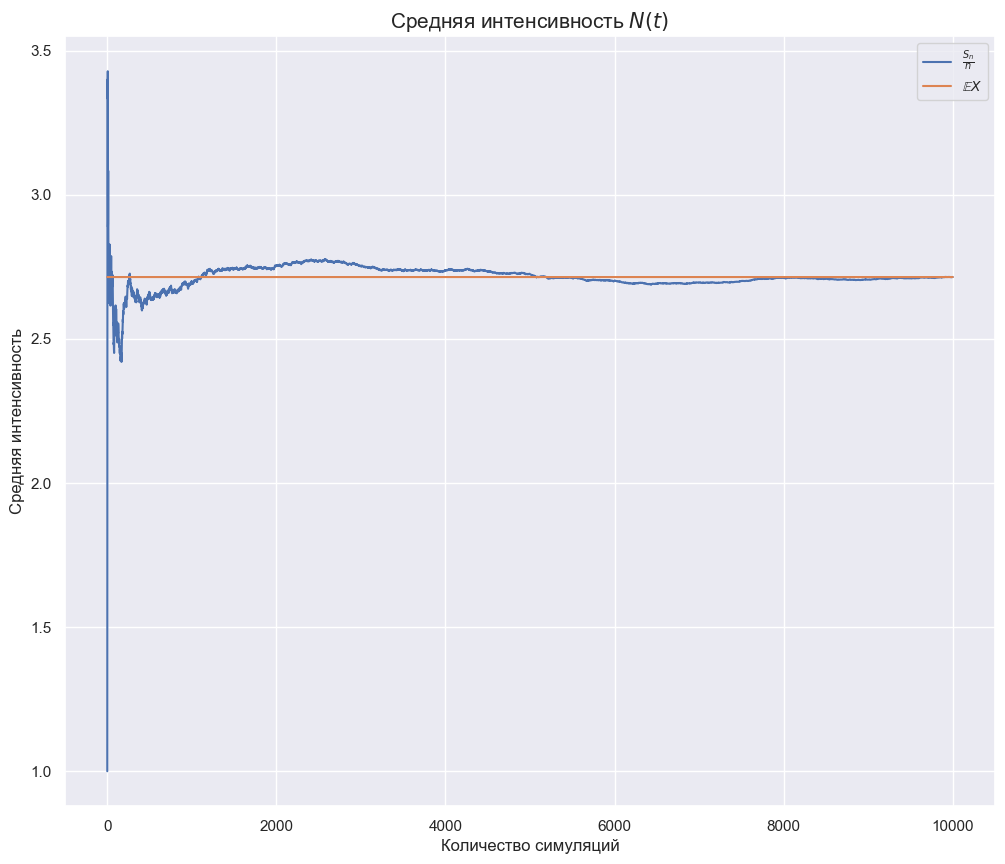

In [25]:
plt.figure(figsize=(12, 10))

sns.lineplot(x=N, y=S_n, label='$\\frac{S_n}{n}$')
sns.lineplot(x=N, y=np.full_like(a=N, fill_value=np.mean(samples), dtype=np.float32), label='$\\mathbb{E}X$')

plt.title('Средняя интенсивность $N(t)$', fontsize=15)
plt.xlabel('Количество симуляций')
plt.ylabel('Средняя интенсивность')
plt.legend(fontsize=10)
plt.show()

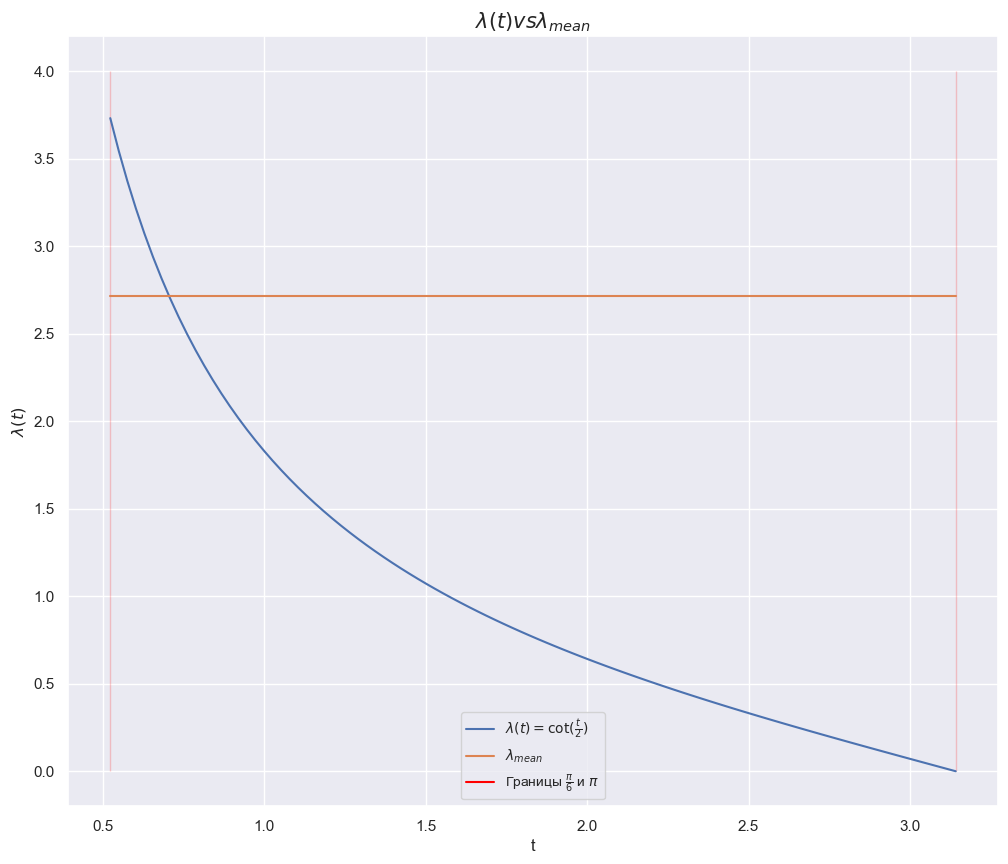

In [26]:
plt.figure(figsize=(12, 10))

x = np.linspace(math.pi / 6, math.pi, 100)
y = 1 / np.tan(x / 2)

sns.lineplot(x=x, y=y, label='$\lambda(t)=\\cot(\\frac{t}{2})$')
sns.lineplot(x=x, y=np.full_like(a=x, fill_value=np.mean(samples)), label='$\lambda_{mean}$')
sns.lineplot(x= [math.pi / 6, math.pi / 6], y = [0, 4], color='red', label='Границы $\\frac{\\pi}{6}$ и $\\pi$')
sns.lineplot(x= [math.pi, math.pi], y = [0, 4], color='red')

plt.xlabel('t')
plt.ylabel('$\lambda(t)$')
plt.legend(fontsize=10)
plt.title('$\lambda(t) vs \lambda_{mean}$', fontsize=15)
plt.show()

$$ \text{Cравнение } \Lambda(t) \text{ и } \lambda_{mean} $$
$$ \Lambda(t) = \int_{\frac{\pi}{6}}^{t} \lambda(\tau)d\tau $$
$$ \Lambda(\pi) = \text{U} =  -2\cdot\ln(\sin(\frac{\pi}{12})\approx 2.703 \approx \lambda_{mean}$$